**Problem statement**
A restaurant consolidator is looking to revamp the B2C portal using intelligent automation tech. This requires a different matrix to identify the star restaurants and generate recommendations. To make sure an effective model can be achieved, it is important to understand the behavior of the data in hand.
There are 2 datasets, data and Country-Code. Dataset data has 19 attributes and Country-Code has two attributes.
You are required to determine certain matrices to identify the star restaurants and generate recommendations.

Importing, Understanding, and Inspecting Data:
1. Perform preliminary data inspection and report the findings as the structure of the data, missing values, duplicates, etc.
2. Based on the findings from the previous questions, identify duplicates and remove them

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset
df=pd.read_excel('data.xlsx')
country_df=pd.read_excel('Country-Code.xlsx')

In [ ]:
country_df

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia
5,148,New Zealand
6,162,Phillipines
7,166,Qatar
8,184,Singapore
9,189,South Africa


In [ ]:
#display the data
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,18279289,BMG - All Day Dining,1,Dehradun,"140 A, Rajpur Road, Jakhan, Dehradun",Jakhan,"Jakhan, Dehradun",78.068890,30.362686,"Chinese, North Indian, Fast Food",0,Indian Rupees(Rs.),No,No,1,4.3,Green,Very Good,63
9547,2300497,Atmosphere Grill Cafe Sheesha,1,Kanpur,"8th Floor, J.S. Tower, 16/106 - Mall Road, Kan...",Mall Road,"Mall Road, Kanpur",80.354002,26.472001,"Indian, Chinese, Continental",0,Indian Rupees(Rs.),No,No,1,3.6,Yellow,Good,34
9548,18312106,UrbanCrave,1,Kanpur,"14/125, The Mall, Mall Road, Colonelganj, Para...",Parade,"Parade, Kanpur",80.342796,26.474986,"Cafe, Continental, Desserts, Ice Cream, Italia...",0,Indian Rupees(Rs.),No,No,1,3.9,Yellow,Good,127
9549,3900245,Deena Chat Bhandar,1,Varanasi,"D-47/184, Luxa Road, Dashaswmedh Road, Varanasi",Dashaswmedh Road,"Dashaswmedh Road, Varanasi",0.000000,0.000000,Street Food,0,Indian Rupees(Rs.),No,No,1,3.8,Yellow,Good,78


In [ ]:
#check the number of rows anad cols
df.shape

(9551, 19)

In [ ]:
#check the different datatypes and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9550 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Price range           9551 non-null   int64  
 15  Aggregate rating     

In [ ]:
#check if the dataset has any missing vlaues
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,1
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [ ]:
#to check for the duplicate values
df.duplicated().sum()

np.int64(0)

##merge the country data

In [ ]:
# Option A: drop if exists
if 'Country' in df.columns:
    df = df.drop(columns=['Country'])

df = df.merge(country_df, on='Country Code', how='left')
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Country_x,Country_y,Country
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",...,No,No,3,4.1,Green,Very Good,1498,Indonesia,Indonesia,Indonesia
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",...,No,No,3,4.6,Dark Green,Excellent,873,Indonesia,Indonesia,Indonesia
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",...,No,No,3,4.9,Dark Green,Excellent,605,Indonesia,Indonesia,Indonesia
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,...,No,No,3,4.2,Green,Very Good,395,Indonesia,Indonesia,Indonesia
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",...,No,No,3,4.3,Green,Very Good,243,Indonesia,Indonesia,Indonesia


In [ ]:
df['Country'] = df['Country_y']
df = df.drop(columns=['Country_x', 'Country_y'])


In [ ]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498,Indonesia
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873,Indonesia
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605,Indonesia
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395,Indonesia
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243,Indonesia


**Performing EDA:**
3. Explore the geographical distribution of the restaurants and identify the cities with the maximum and minimum number of restaurants
4. Restaurant franchising is a thriving venture. So, it is very important to explore the franchise with most national presence
5. Find out the ratio between restaurants that allow table booking vs. those that do not allow table booking
6. Find out the percentage of restaurants providing online delivery
7. Calculate the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver

In [ ]:
#city count
city_counts=df['City'].value_counts()
city_counts

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
...,...
Vernonia,1
Dicky Beach,1
Inverloch,1


In [ ]:
#identify the city with max number of restaurants
max_city=city_counts.idxmax(),city_counts.max()
max_city

('New Delhi', 5473)

In [ ]:
#identify the city with min number of restaurants
min_city=city_counts.idxmin(),city_counts.min()
min_city

('Bandung', 1)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

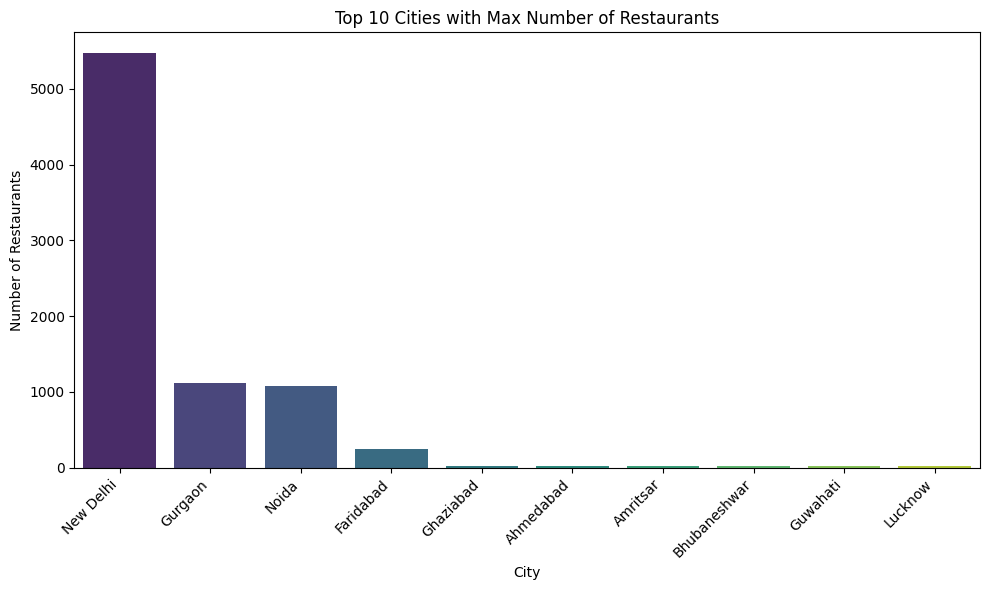

In [ ]:
#Top 10 cities with max and min number of restaurants displayed in a chart
city_counts=df['City'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=city_counts.index,y=city_counts.values,palette='viridis')
plt.title('Top 10 Cities with Max Number of Restaurants')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()


##franchise with most national presence

In [ ]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Price range', 'Aggregate rating',
       'Rating color', 'Rating text', 'Votes'],
      dtype='object')

In [ ]:
df.groupby('Restaurant Name')['Country'].nunique().sort_values(ascending=False).head(10)

,Country
Restaurant Name,
Hard Rock Cafe,3
Nando's,2
Tipu Sultan,2
The Breakfast Club,2
The Cafe,2
Punjab Restaurant,2
The National,2
Indian Coffee House,2
The Crab Shack,2


 ratio between restaurants that allow table booking vs. those that do not allow table booking

In [ ]:
df['Has Table booking'].value_counts(normalize=True)*100

,proportion
Has Table booking,
No,87.875615
Yes,12.124385


percentage of restaurants providing online delivery

In [ ]:
df['Has Online delivery'].value_counts(normalize=True)*100

,proportion
Has Online delivery,
No,74.337766
Yes,25.662234


difference in number of votes for the restaurants that deliver and the restaurants that do not deliver

In [ ]:
votes=df.groupby('Has Online delivery')['Votes'].mean()
votes

,Votes
Has Online delivery,
No,138.131127
Yes,211.307222


In [ ]:
print(votes['Yes']-votes['No'])

73.17609478166429


 top 10 cuisines served across cities?

In [ ]:
top_cuisines=df['Cuisines'].dropna().str.split(', ').explode().value_counts().head(10)
top_cuisines

,count
Cuisines,
North Indian,3960
Chinese,2735
Fast Food,1986
Mughlai,995
Italian,764
Bakery,745
Continental,736
Cafe,703
Desserts,653


/tmp/ipython-input-2451039871.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines,y=top_cuisines.values,palette='viridis')


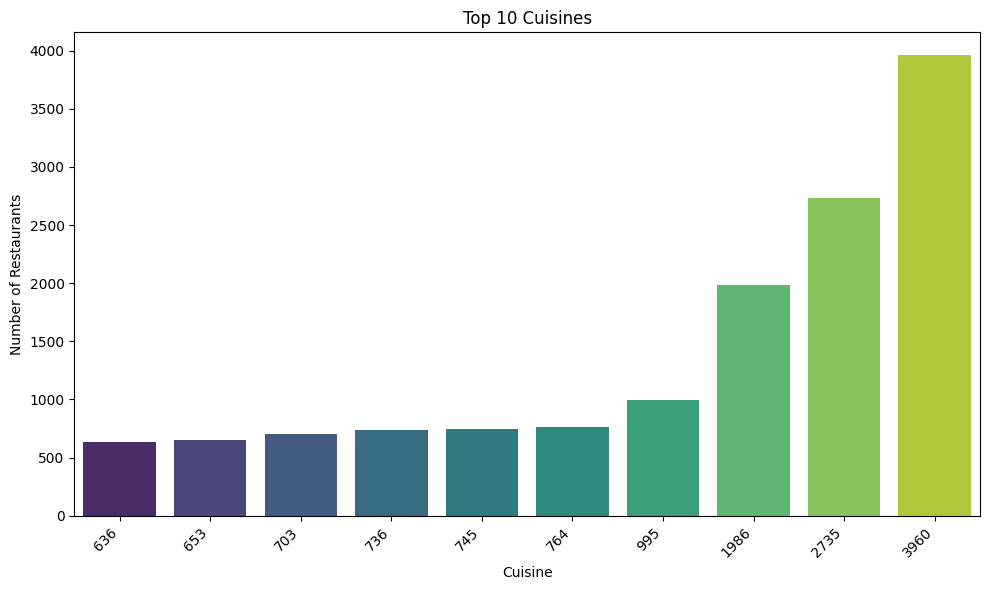

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisines,y=top_cuisines.values,palette='viridis')
plt.title('Top 10 Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

maximum and minimum number of cuisines that a restaurant serve





In [ ]:
df['Cuisine_count']=df['Cuisines'].dropna().apply(lambda x:len(x.split(', ')))
print('Max count is: ',df['Cuisine_count'].max())
print('Min count is: ',df['Cuisine_count'].min())

Max count is:  8.0
Min count is:  1.0


In [ ]:


# Define the cuisine column name and the DataFrame

cuisine_col = 'Cuisines'

df_processed = df.copy() # Use df as the primary DataFrame

if cuisine_col in df_processed.columns:

    # Count how many cuisines each restaurant has

    df_processed["num_cuisines"] = df_processed[cuisine_col].fillna("").apply(

        lambda x: len([c for c in str(x).split(',') if c.strip() != ""])

    )

    print("Description of number of cuisines per restaurant:")

    display(df_processed["num_cuisines"].describe())

    max_cuisines = df_processed["num_cuisines"].max()

    min_cuisines = df_processed["num_cuisines"].min()

    print(f"\nMaximum number of cuisines served by a restaurant: {max_cuisines}")

    print(f"Minimum number of cuisines served by a restaurant: {min_cuisines}")

    # Which restaurants have max/min cuisines?

    print("\nRestaurants with maximum cuisines:")

    display(

        df_processed[df_processed["num_cuisines"] == max_cuisines][

            ["Restaurant Name", "City", cuisine_col, "num_cuisines"]

        ].head(10)

    )

else:

    print("Cuisine column not found for counting.")

Description of number of cuisines per restaurant:


,num_cuisines
count,9551.000000
mean,2.063658
std,1.094072
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,8.000000



Maximum number of cuisines served by a restaurant: 8
Minimum number of cuisines served by a restaurant: 0

Restaurants with maximum cuisines:


,Restaurant Name,City,Cuisines,num_cuisines
990,R' ADDA,Mumbai,"Street Food, Burger, Desserts, Italian, Pizza,...",8
1255,Mumbai Vibe,Mumbai,"Cafe, Continental, North Indian, Italian, Chin...",8
1456,Marble,Johannesburg,"Continental, South African, Beverages, Dessert...",8
2783,Bikanervala,Gurgaon,"North Indian, South Indian, Fast Food, Street ...",8
3271,Indian Summer Cafe,Patna,"Continental, Cafe, Italian, Pizza, North India...",8
3359,Bikanervala,New Delhi,"North Indian, South Indian, Fast Food, Street ...",8
3389,Bikanervala,New Delhi,"North Indian, South Indian, Fast Food, Street ...",8
3406,Bikanervala,New Delhi,"North Indian, South Indian, Fast Food, Street ...",8
3425,Bikanervala,New Delhi,"North Indian, South Indian, Fast Food, Street ...",8
3442,Bikanervala,New Delhi,"North Indian, South Indian, Fast Food, Street ...",8


most served cuisine across the restaurant for each city

In [ ]:
# Assuming 'cuisine_col' is defined as 'Cuisines' from previous cells.

# Replacing 'merged_df' with 'df' as 'df' is the main DataFrame.

if cuisine_col in df.columns and "City" in df.columns:

    # Explode cuisines while keeping city

    city_cuisine = (

        df[["City", cuisine_col]]

        .dropna()

    )

    city_cuisine = city_cuisine.assign(

        Cuisine=city_cuisine[cuisine_col].str.split(',')

    ).explode("Cuisine")

    city_cuisine["Cuisine"] = city_cuisine["Cuisine"].str.strip()

    # Count cuisines per city

    city_cuisine_counts = (

        city_cuisine

        .groupby(["City", "Cuisine"])

        .size()

        .reset_index(name="count")

    )

    # For each city, pick cuisine with maximum count

    idx = city_cuisine_counts.groupby("City")["count"].idxmax()

    most_served_per_city = city_cuisine_counts.loc[idx] \
    .sort_values("count", ascending=False)

    print("Most served cuisine in each city:")

    display(most_served_per_city.head(20))

else:

    print("Columns 'City' or 'Cuisines' missing.")

Most served cuisine in each city:


,City,Cuisine,count
1217,New Delhi,North Indian,2425
1274,Noida,North Indian,532
753,Gurgaon,North Indian,508
646,Faridabad,North Indian,122
1491,Ranchi,North Indian,16
37,Agra,North Indian,15
1343,Patna,North Indian,15
104,Amritsar,North Indian,15
198,Aurangabad,North Indian,15
850,Jaipur,Continental,13


 distribution cost across the restaurants

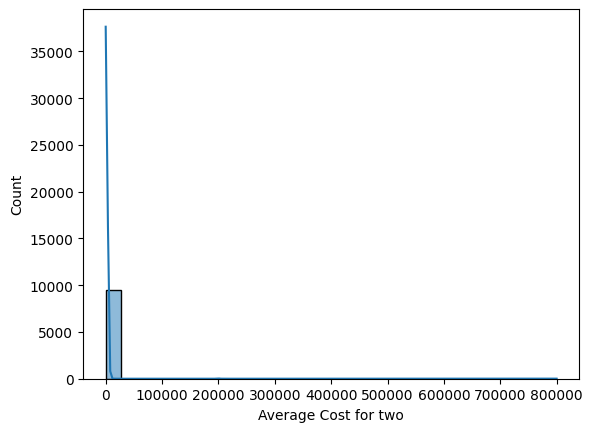

In [ ]:
sns.histplot(df['Average Cost for two'],bins=30,kde=True)
plt.show()

ratings distributed among the various factors

In [5]:
rating_col_candidates = [c for c in df.columns if 'rating' in c.lower()]

print("Possible rating columns:", rating_col_candidates)

rating_col = "Aggregate rating"   # adjust if needed

online_col = "Has Online delivery" # Define online delivery column name

table_col = "Has Table booking"   # Define table booking column name



Possible rating columns: ['Aggregate rating', 'Rating color', 'Rating text']



Rating statistics:


,Aggregate rating
count,9551.000000
mean,2.666370
std,1.516378
min,0.000000
25%,2.500000
50%,3.200000
75%,3.700000
max,4.900000


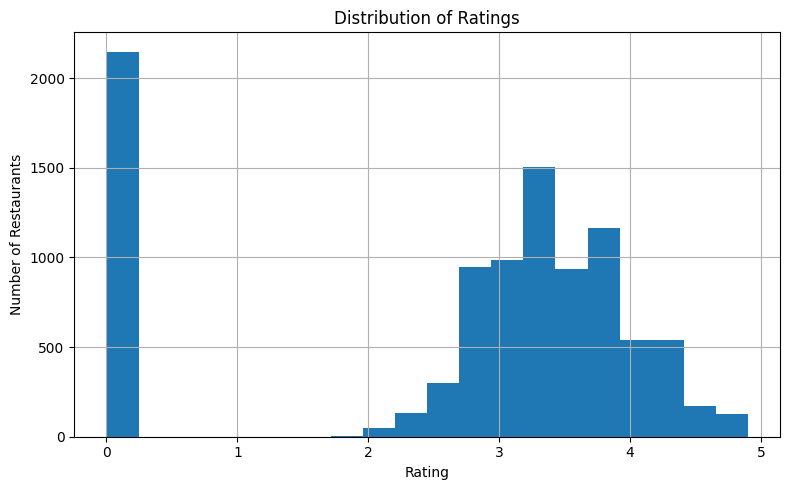

In [6]:
print("\nRating statistics:")

display(df[rating_col].describe())

# Histogram of ratings

plt.figure(figsize=(8, 5))

df[rating_col].dropna().hist(bins=20)

plt.title("Distribution of Ratings")

plt.xlabel("Rating")

plt.ylabel("Number of Restaurants")

plt.tight_layout()

plt.show()

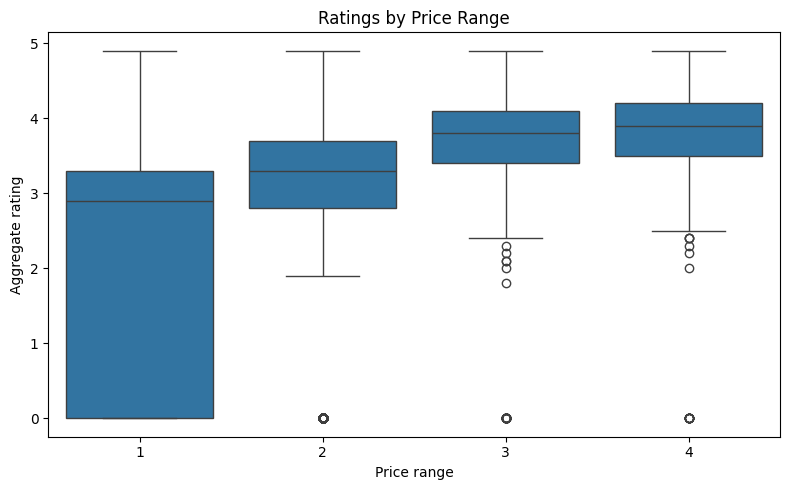

In [7]:
#rating vs price range

if "Price range" in df.columns:
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=df, x="Price range", y=rating_col)

    plt.title("Ratings by Price Range")

    plt.tight_layout()

    plt.show()

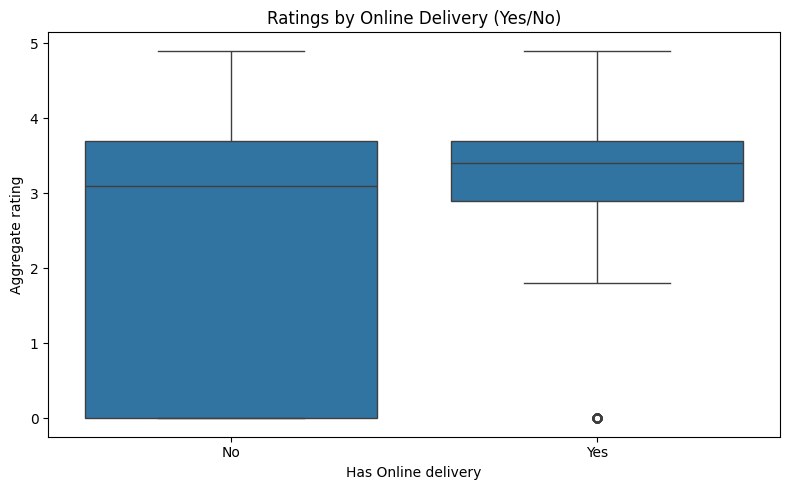

In [8]:
#rating vs online delivery
if online_col in df.columns:
  plt.figure(figsize=(8, 5))

  sns.boxplot(data=df, x=online_col, y=rating_col)

  plt.title("Ratings by Online Delivery (Yes/No)")

  plt.tight_layout()

  plt.show()

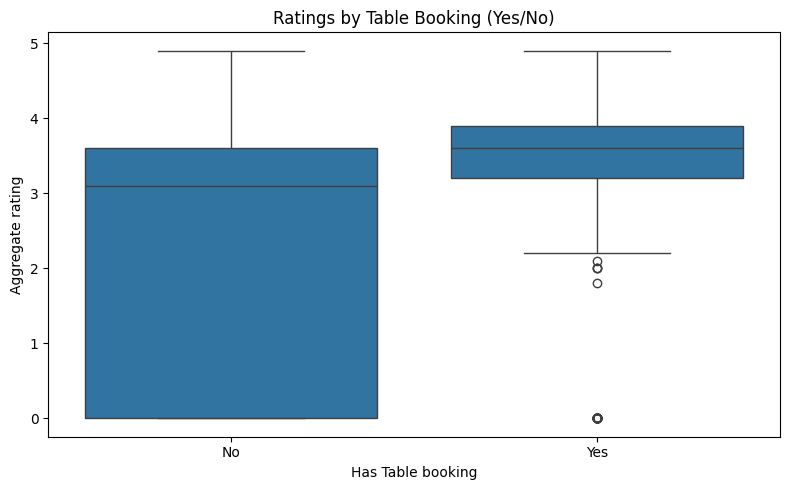

In [9]:
#rating vs table booking
if table_col in df.columns:
  plt.figure(figsize=(8, 5))
  sns.boxplot(data=df, x=table_col, y=rating_col)

  plt.title("Ratings by Table Booking (Yes/No)")

  plt.tight_layout()

  plt.show()

Explain the factors in the data that may have an effect on ratings. For example, number of cuisines, cost, delivery option, etc.

In [10]:
import numpy as np

# Identify numeric columns

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)

# Correlation of numeric variables with rating

if rating_col in numeric_cols:

    corr = (

         df[numeric_cols]

        .corr()[rating_col]

        .sort_values(ascending=False)

    )

    print("\nCorrelation of numeric variables with rating:")

    display(corr)

Numeric columns: ['Restaurant ID', 'Country Code', 'Longitude', 'Latitude', 'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']

Correlation of numeric variables with rating:


,Aggregate rating
Aggregate rating,1.000000
Price range,0.437944
Votes,0.313691
Country Code,0.282189
Average Cost for two,0.051792
Latitude,0.000516
Longitude,-0.116818
Restaurant ID,-0.326212


In [11]:
# Compare average rating by key categorical factors

def mean_rating_by(col):

    if col in df.columns and rating_col in df.columns:

        result = (

             df

            .groupby(col)[rating_col]

            .mean()

            .sort_values(ascending=False)

        )

        print(f"\nAverage {rating_col} by {col}:")

        display(result.head(10))

    else:

        print(f"Column '{col}' not found or rating column missing.")

# Apply function to important factors

mean_rating_by("Price range")

mean_rating_by(online_col)

mean_rating_by(table_col)

mean_rating_by("City")


Average Aggregate rating by Price range:


,Aggregate rating
Price range,
4,3.817918
3,3.683381
2,2.941054
1,1.999887



Average Aggregate rating by Has Online delivery:


,Aggregate rating
Has Online delivery,
Yes,3.248837
No,2.465296



Average Aggregate rating by Has Table booking:


,Aggregate rating
Has Table booking,
Yes,3.441969
No,2.559359



Average Aggregate rating by City:


,Aggregate rating
City,
Inner City,4.900000
Quezon City,4.800000
Makati City,4.650000
Pasig City,4.633333
Mandaluyong City,4.625000
Beechworth,4.600000
London,4.535000
Taguig City,4.525000
Secunderabad,4.500000
